In [1]:
import numpy as np
from IQAEBinom import IQAEBinom
import matplotlib.pyplot as plt
import matplotlib.ticker as ptick 
import pickle
from BiasCorrection import BiasExact
import datetime
import os
import pandas as pd

In [2]:
epsilon = 0.001
nEstim = 10000
alpha = 0.05
nShotUnit = 1

In [3]:
ps = np.linspace(0.001, 0.999, 201)

In [4]:
errAvgs = np.array([])
errStds = np.array([])
biasesMonte = np.array([])
for p in ps:
    print(p, datetime.datetime.now())
    results = np.array([])

    for i in range(nEstim):
        result = IQAEBinom(p, epsilon, alpha, nShotUnit, confint_method="chernoff")
        results = np.append(results, result)

    resFileName = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue" + str(p) + "_epsilon0001_alpha005.dat"
    with open(resFileName, 'wb') as f:
        pickle.dump(results, f) 
    biases = [BiasExact(p, r["nGrover"][-1], r["nShots"][-1]) for r in results]    
    biasesMonte = np.append(biasesMonte, np.mean(biases))
    errs = [r["Estimate"] - p for r in results]
    errAvgs = np.append(errAvgs, np.mean(errs))
    errStds = np.append(errStds, np.std(errs))


0.001 2023-08-30 14:57:25.058634
0.2505 2023-08-30 14:58:23.585357
0.5 2023-08-30 15:03:21.176992
0.7494999999999999 2023-08-30 15:05:28.951726
0.999 2023-08-30 15:10:20.691700


In [4]:
dirPath = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230830_IQAEVariousP_nShotUnit1"
files = os.listdir(dirPath)
print(files)

psInFiles = np.array([])
for f in files:
    psInFiles = np.append(psInFiles, float(f.split('_')[2][5:]))

print(psInFiles)

['results_IQAE_pTrue0.001_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.00599_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.01098_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.015969999999999998_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.02096_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.02595_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.03094_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.03593_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.04092_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.04591_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.0509_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.055889999999999995_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.06088_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.06587_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.07085999999999999_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.07585_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.08084_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.08582999999999999_epsilon

In [5]:
errAvgs = np.array([])
errStds = np.array([])

for p in ps:
    print(p)
    idRes = np.where(np.abs(psInFiles - p) < 1e-6)[0]
    if len(idRes) != 1:
        raise Exception("multiple ID:p=" + str(p) + ", ID=" + str(idRes))
    with open(dirPath + "/" + files[idRes[0]], 'rb') as f:
        res = pickle.load(f)
    errs = [r["Estimate"] - p for r in res]
    errAvgs = np.append(errAvgs, np.mean(errs))
    errStds = np.append(errStds, np.std(errs))

0.001
0.00599
0.01098
0.015969999999999998
0.02096
0.02595
0.03094
0.03593
0.04092
0.04591
0.0509
0.055889999999999995
0.06088
0.06587
0.07085999999999999
0.07585
0.08084
0.08582999999999999
0.09082
0.09580999999999999
0.1008
0.10579
0.11077999999999999
0.11577
0.12075999999999999
0.12574999999999997
0.13074
0.13573
0.14071999999999998
0.14570999999999998
0.1507
0.15569
0.16068
0.16566999999999998
0.17065999999999998
0.17565
0.18064
0.18563
0.19061999999999998
0.19560999999999998
0.2006
0.20559
0.21058
0.21556999999999998
0.22055999999999998
0.22554999999999997
0.23054
0.23553
0.24051999999999998
0.24550999999999998
0.25049999999999994
0.25549
0.26048
0.26547
0.27046
0.27545
0.28043999999999997
0.28542999999999996
0.29041999999999996
0.29541
0.3004
0.30539
0.31038
0.31537
0.32036
0.32535
0.33033999999999997
0.33532999999999996
0.34031999999999996
0.34530999999999995
0.3503
0.35529
0.36028
0.36527
0.37026
0.37525
0.38023999999999997
0.38522999999999996
0.39021999999999996
0.395209999999

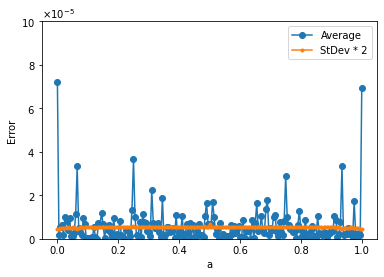

In [15]:
ax = plt.gca()
plt.plot(ps, np.abs(errAvgs), marker="o", label="Average")
plt.plot(ps, errStds * 2 / np.sqrt(nEstim), marker=".", label="StDev * 2")

ax.set_xlabel("a")
ax.set_ylabel("Error")

#ax.set_ylim(1e-9, 1e-4)
#plt.yscale('log')
ax.set_ylim(0, 1e-4)
plt.legend()

ax.yaxis.set_major_formatter(ptick.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="y", scilimits=(-5,-5)) 

plt.show()

In [9]:
df = pd.DataFrame({"P":ps, "ErrMean":errAvgs, "ErrMeanAbs":np.abs(errAvgs), "ErrStDev":errStds, "ErrStDevDevSqrtN":errStds / np.sqrt(nEstim)})
df.to_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230830_IQAEVariousP_nShotUnit1/summary/errMeanStd.csv", index=False)
df.sort_values("ErrMeanAbs", ascending=False)[:20]

,P,ErrMean,ErrMeanAbs,ErrStDev,ErrStDevDevSqrtN
0,0.00100,-0.000072,0.000072,0.000226,0.000002
200,0.99900,0.000070,0.000070,0.000226,0.000002
50,0.25050,0.000037,0.000037,0.000287,0.000003
187,0.93413,0.000034,0.000034,0.000223,0.000002
13,0.06587,-0.000033,0.000033,0.000221,0.000002
150,0.74950,-0.000029,0.000029,0.000282,0.000003
62,0.31038,-0.000023,0.000023,0.000274,0.000003
69,0.34531,-0.000019,0.000019,0.000267,0.000003
138,0.68962,0.000018,0.000018,0.000277,0.000003
195,0.97405,0.000017,0.000017,0.000238,0.000002


0.4173807376795557


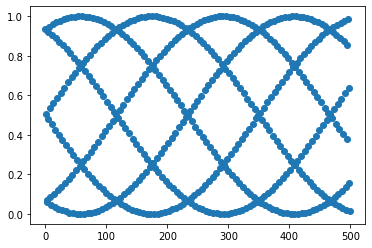

In [41]:
theta093413 = np.arcsin(np.sqrt(0.93413))
print(theta093413 / (np.pi))

ax = plt.gca()
plt.scatter(np.arange(0, 500), np.sin((2 * np.arange(0, 500) + 1) * theta093413) ** 2)
plt.show()

In [34]:
idRes = np.where(np.abs(psInFiles - 0.93413) < 1e-6)[0]
with open(dirPath + "/" + files[idRes[0]], 'rb') as f:
    results093413 = pickle.load(f)

(array([0.000e+00, 2.000e+00, 4.000e+00, 4.400e+01, 1.580e+02, 2.489e+03,
        2.649e+03, 6.990e+02, 6.860e+02, 3.390e+02, 1.610e+02, 2.310e+02,
        7.300e+01, 5.000e+01, 9.200e+01, 7.400e+01, 5.400e+01, 4.800e+01,
        6.300e+01, 3.800e+01, 1.040e+02, 5.800e+01, 2.500e+01, 4.100e+01,
        2.390e+02, 2.180e+02, 2.610e+02, 1.100e+02, 5.000e+01, 3.020e+02,
        6.500e+01, 3.830e+02, 4.900e+01, 0.000e+00, 8.600e+01, 1.100e+01,
        2.600e+01, 5.000e+00, 2.000e+00, 1.000e+00, 4.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([ 70.,  75.,  80.,  85.,  90.,  95., 100., 105., 110., 115., 120.,
        125., 130., 135., 140., 145., 150., 155., 160., 165., 170., 175.,
        180., 185., 190., 195., 200., 205., 210., 215., 220., 225., 230.,
        235., 240., 245., 250., 255., 260., 265., 270., 275., 280., 285.,
        290., 295., 300.]),
 <BarContainer object of 46 artists>)

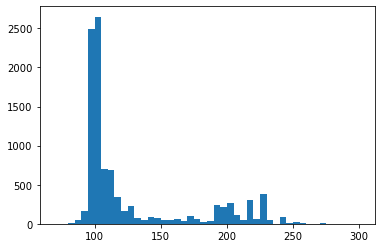

In [39]:
nGFinals = np.array([r["nGrover"][-1] for r in results093413])
plt.hist(nGFinals, range=(70, 300), bins=46)

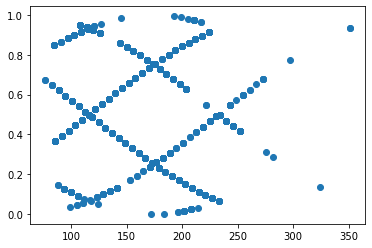

In [40]:
ax = plt.gca()
plt.scatter(nGFinals, np.sin((2 * nGFinals + 1) * theta093413) ** 2)
plt.show()

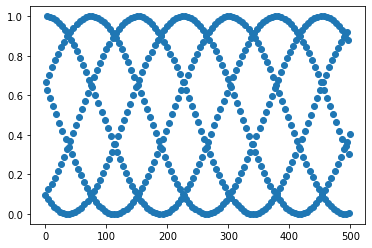

In [46]:
ax = plt.gca()
plt.scatter(np.arange(0, 500), np.sin((2 * np.arange(0, 500) + 1) * 1 / np.pi) ** 2)
plt.show()

0.6548514245838999 0.30011478811169934


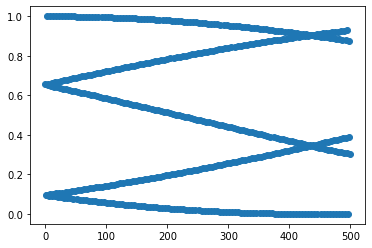

In [107]:
pRandom = np.random.uniform()
thetaRandom = np.arcsin(np.sqrt(pRandom))
print(pRandom, thetaRandom / np.pi)

ax = plt.gca()
plt.scatter(np.arange(0, 500), np.sin((2 * np.arange(0, 500) + 1) * thetaRandom) ** 2)
plt.show()